In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Loading the dataset

In [2]:
dataset=pd.read_csv("Walmart dataset.csv", delimiter=';')

In [3]:
dataset.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender',
       'product_line', 'unit_price', 'quantity', 'vat', 'total', 'dtme', 'tme',
       'payment_method', 'cogs', 'gross_margin_pct', 'gross_income', 'rating',
       'time_of_day', 'day_name', 'month_name'],
      dtype='object')

In [4]:
dataset

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,vat,total,dtme,tme,payment_method,cogs,gross_margin_pct,gross_income,rating,time_of_day,day_name,month_name
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05 00:00:00,13:08:00,Ewallet,522.83,4.7619,26.1415,9.1,afternoon,Saturday,January
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08 00:00:00,10:29:00,Cash,76.40,4.7619,3.8200,9.6,morning,Friday,March
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03 00:00:00,13:23:00,Credit card,324.31,4.7619,16.2155,7.4,afternoon,Sunday,March
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27 00:00:00,20:33:00,Ewallet,465.76,4.7619,23.2880,8.4,evening,Sunday,January
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08 00:00:00,10:37:00,Ewallet,604.17,4.7619,30.2085,5.3,morning,Friday,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,2019-01-29 00:00:00,13:46:00,Ewallet,40.35,4.7619,2.0175,6.2,afternoon,Tuesday,January
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,2019-03-02 00:00:00,17:16:00,Ewallet,973.80,4.7619,48.6900,4.4,evening,Saturday,March
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2019-02-09 00:00:00,13:22:00,Cash,31.84,4.7619,1.5920,7.7,afternoon,Saturday,February
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2019-02-22 00:00:00,15:33:00,Cash,65.82,4.7619,3.2910,4.1,afternoon,Friday,February


# Checking for Null Values

In [5]:
dataset.isnull().sum()

invoice_id          0
branch              0
city                0
customer_type       0
gender              0
product_line        0
unit_price          0
quantity            0
vat                 0
total               0
dtme                0
tme                 0
payment_method      0
cogs                0
gross_margin_pct    0
gross_income        0
rating              0
time_of_day         0
day_name            0
month_name          0
dtype: int64

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   invoice_id        1000 non-null   object 
 1   branch            1000 non-null   object 
 2   city              1000 non-null   object 
 3   customer_type     1000 non-null   object 
 4   gender            1000 non-null   object 
 5   product_line      1000 non-null   object 
 6   unit_price        1000 non-null   float64
 7   quantity          1000 non-null   int64  
 8   vat               1000 non-null   float64
 9   total             1000 non-null   float64
 10  dtme              1000 non-null   object 
 11  tme               1000 non-null   object 
 12  payment_method    1000 non-null   object 
 13  cogs              1000 non-null   float64
 14  gross_margin_pct  1000 non-null   float64
 15  gross_income      1000 non-null   float64
 16  rating            1000 non-null   float64
 

In [7]:
print(f"Total Rows:{dataset.shape[0]}\nTotal Columns:{dataset.shape[1]}")

Total Rows:1000
Total Columns:20


In [8]:
# Checking duplicate values
dataset.duplicated().sum()

np.int64(0)

# Univariate Analysis

In [9]:
def quanQual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        #print(columnName)
        if(dataset[columnName].dtype=='O'):
            #print("qual")
            qual.append(columnName)
        else:
            #print("quan")
            quan.append(columnName)
    return quan,qual

In [10]:
quan,qual=quanQual(dataset)

In [11]:
quan

['unit_price',
 'quantity',
 'vat',
 'total',
 'cogs',
 'gross_margin_pct',
 'gross_income',
 'rating']

In [12]:
qual

['invoice_id',
 'branch',
 'city',
 'customer_type',
 'gender',
 'product_line',
 'dtme',
 'tme',
 'payment_method',
 'time_of_day',
 'day_name',
 'month_name']

In [13]:
dataset["unit_price"].mean()

np.float64(55.67213)

In [14]:
dataset.describe()

,unit_price,quantity,vat,total,cogs,gross_margin_pct,gross_income,rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.0000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.7619,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.0000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.7619,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.7619,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.7619,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.7619,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.7619,49.650000,10.00000


In [15]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Min","Q1:25%","Q2:50%","Q3:75%","99%","Q4:100%","IQR",
                                "1.5rule","Lesser","Greater","Min","Max","Skew","Kurtosis","Var","Std"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
    descriptive[columnName]["Min"]=dataset[columnName].min()
    descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
    descriptive[columnName]["99%"]=np.percentile(dataset[columnName],99)
    descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]-descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"]=dataset[columnName].min()
    descriptive[columnName]["Max"]=dataset[columnName].max()
    descriptive[columnName]["Skew"]=dataset[columnName].skew()
    descriptive[columnName]["Kurtosis"]=dataset[columnName].kurtosis()
    descriptive[columnName]["Var"]=dataset[columnName].var()
    descriptive[columnName]["Std"]=dataset[columnName].std()

In [16]:
descriptive

,unit_price,quantity,vat,total,cogs,gross_margin_pct,gross_income,rating
Mean,55.67213,5.51,15.379369,322.966749,307.58738,4.7619,15.379369,6.9727
Median,55.23,5.0,12.088,253.848,241.76,4.7619,12.088,7.0
Mode,83.77,10,4.154,87.234,83.08,4.7619,4.154,6.0
Min,10.08,1,0.5085,10.6785,10.17,4.7619,0.5085,4.0
Q1:25%,32.875,3.0,5.924875,124.422375,118.4975,4.7619,5.924875,5.5
Q2:50%,55.23,5.0,12.088,253.848,241.76,4.7619,12.088,7.0
Q3:75%,77.935,8.0,22.44525,471.35025,448.905,4.7619,22.44525,8.5
99%,99.7102,10.0,45.25075,950.26575,905.015,4.7619,45.25075,9.9
Q4:100%,99.96,10.0,49.65,1042.65,993.0,4.7619,49.65,10.0
IQR,45.06,5.0,16.520375,346.927875,330.4075,0.0,16.520375,3.0


In [17]:
def Univariate(dataset,quan):
    descriptive=pd.DataFrame(index=["Mean","Median","Mode","Min","Q1:25%","Q2:50%","Q3:75%","99%","Q4:100%","IQR",
                                "1.5rule","Lesser","Greater","Min","Max","Skew","Kurtosis","Var","Std"],columns=quan)
    for columnName in quan:
        descriptive[columnName]["Mean"]=dataset[columnName].mean()
        descriptive[columnName]["Median"]=dataset[columnName].median()
        descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
        descriptive[columnName]["Min"]=dataset[columnName].min()
        descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
        descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
        descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
        descriptive[columnName]["99%"]=np.percentile(dataset[columnName],99)
        descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
        descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]-descriptive[columnName]["Q1:25%"]
        descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
        descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
        descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
        descriptive[columnName]["Min"]=dataset[columnName].min()
        descriptive[columnName]["Max"]=dataset[columnName].max()
        descriptive[columnName]["Skew"]=dataset[columnName].skew()
        descriptive[columnName]["Kurtosis"]=dataset[columnName].kurtosis()
        descriptive[columnName]["Var"]=dataset[columnName].var()
        descriptive[columnName]["Std"]=dataset[columnName].std()
    return descriptive

In [18]:
Univariate(dataset,quan)

,unit_price,quantity,vat,total,cogs,gross_margin_pct,gross_income,rating
Mean,55.67213,5.51,15.379369,322.966749,307.58738,4.7619,15.379369,6.9727
Median,55.23,5.0,12.088,253.848,241.76,4.7619,12.088,7.0
Mode,83.77,10,4.154,87.234,83.08,4.7619,4.154,6.0
Min,10.08,1,0.5085,10.6785,10.17,4.7619,0.5085,4.0
Q1:25%,32.875,3.0,5.924875,124.422375,118.4975,4.7619,5.924875,5.5
Q2:50%,55.23,5.0,12.088,253.848,241.76,4.7619,12.088,7.0
Q3:75%,77.935,8.0,22.44525,471.35025,448.905,4.7619,22.44525,8.5
99%,99.7102,10.0,45.25075,950.26575,905.015,4.7619,45.25075,9.9
Q4:100%,99.96,10.0,49.65,1042.65,993.0,4.7619,49.65,10.0
IQR,45.06,5.0,16.520375,346.927875,330.4075,0.0,16.520375,3.0


# Checking for Outliers

In [19]:
Lesser=[]
Greater=[]
for columnName in quan:
    if(descriptive[columnName]["Min"]<descriptive[columnName]["Lesser"]).any():
        Lesser.append(columnName)
    if(descriptive[columnName]["Max"]>descriptive[columnName]["Greater"]).any():
        Greater.append(columnName)

In [20]:
Lesser

[]

In [21]:
Greater

['vat', 'total', 'cogs', 'gross_income']

In [22]:
def Finding_outliers(descriptive,quan):
    Lesser=[]
    Greater=[]
    for columnName in quan:
        if(descriptive[columnName]["Min"]<descriptive[columnName]["Lesser"]).any():
            Lesser.append(columnName)
        if(descriptive[columnName]["Max"]>descriptive[columnName]["Greater"]).any():
            Greater.append(columnName)
    return Lesser,Greater
        

In [23]:
Lesser,Greater=Finding_outliers(descriptive,quan)

In [24]:
print("Lesser:",Lesser)
print("Greater:",Greater)

Lesser: []
Greater: ['vat', 'total', 'cogs', 'gross_income']


# Replacing the outliers

In [25]:
for columnName in Lesser:
    dataset.loc[dataset[columnName]<descriptive[columnName]["Lesser"],columnName]=descriptive[columnName]["Lesser"]
for columnName in Greater:
    dataset.loc[dataset[columnName]>descriptive[columnName]["Greater"],columnName]=descriptive[columnName]["Greater"]

In [26]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Min","Q1:25%","Q2:50%","Q3:75%","99%","Q4:100%","IQR",
                                "1.5rule","Lesser","Greater","Min","Max","Skew","Kurtosis","Var","Std"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
    descriptive[columnName]["Min"]=dataset[columnName].min()
    descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
    descriptive[columnName]["99%"]=np.percentile(dataset[columnName],99)
    descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]-descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"]=dataset[columnName].min()
    descriptive[columnName]["Max"]=dataset[columnName].max()
    descriptive[columnName]["Skew"]=dataset[columnName].skew()
    descriptive[columnName]["Kurtosis"]=dataset[columnName].kurtosis()
    descriptive[columnName]["Var"]=dataset[columnName].var()
    descriptive[columnName]["Std"]=dataset[columnName].std()

In [27]:
def Handle_outliers(dataset,descriptive,quan):
    for columnName in Lesser:
        dataset.loc[dataset[columnName]<descriptive[columnName]["Lesser"],columnName]=descriptive[columnName]["Lesser"]
    for columnName in Greater:
        dataset.loc[dataset[columnName]>descriptive[columnName]["Greater"],columnName]=descriptive[columnName]["Greater"]
    return dataset
dataset=Handle_outliers(dataset,descriptive,quan)
dataset


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,vat,total,dtme,tme,payment_method,cogs,gross_margin_pct,gross_income,rating,time_of_day,day_name,month_name
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.141500,548.971500,2019-01-05 00:00:00,13:08:00,Ewallet,522.83000,4.7619,26.141500,9.1,afternoon,Saturday,January
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.820000,80.220000,2019-03-08 00:00:00,10:29:00,Cash,76.40000,4.7619,3.820000,9.6,morning,Friday,March
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.215500,340.525500,2019-03-03 00:00:00,13:23:00,Credit card,324.31000,4.7619,16.215500,7.4,afternoon,Sunday,March
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.288000,489.048000,2019-01-27 00:00:00,20:33:00,Ewallet,465.76000,4.7619,23.288000,8.4,evening,Sunday,January
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.208500,634.378500,2019-02-08 00:00:00,10:37:00,Ewallet,604.17000,4.7619,30.208500,5.3,morning,Friday,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.017500,42.367500,2019-01-29 00:00:00,13:46:00,Ewallet,40.35000,4.7619,2.017500,6.2,afternoon,Tuesday,January
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,47.225813,991.742062,2019-03-02 00:00:00,17:16:00,Ewallet,944.51625,4.7619,47.225813,4.4,evening,Saturday,March
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.592000,33.432000,2019-02-09 00:00:00,13:22:00,Cash,31.84000,4.7619,1.592000,7.7,afternoon,Saturday,February
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.291000,69.111000,2019-02-22 00:00:00,15:33:00,Cash,65.82000,4.7619,3.291000,4.1,afternoon,Friday,February


In [28]:
Lesser,Greater=Finding_outliers(descriptive,quan)

In [29]:
print("Lesser:",Lesser)
print("Greater:",Greater)

Lesser: []
Greater: []


# Exploratory Data analysis

# Univariate Analysis

# 1. Which city contributes most sales records?

In [30]:
dataset["city"].value_counts()

city
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

# 2. Is the dataset balanced between male and female?

In [31]:
dataset["gender"].value_counts()

gender
Female    501
Male      499
Name: count, dtype: int64

# 3. Which group is higher in customer type: Member or Normal?

In [32]:
dataset["customer_type"].value_counts()

customer_type
Member    501
Normal    499
Name: count, dtype: int64

# 4. Which month has maximum sales activity?

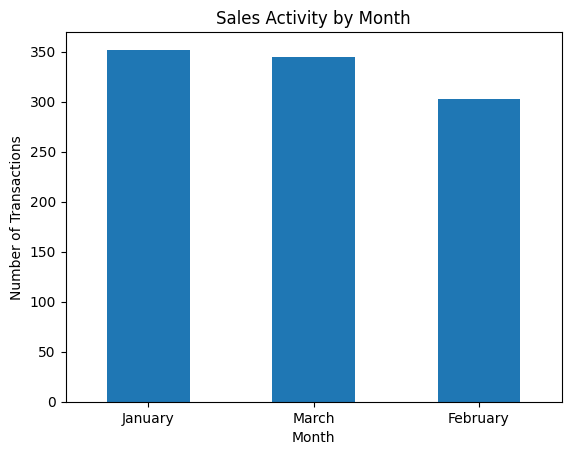

In [33]:
import matplotlib.pyplot as plt

dataset['month_name'].value_counts().plot(kind='bar')

plt.title("Sales Activity by Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

# 5. What is the overall distribution of invoice amounts?

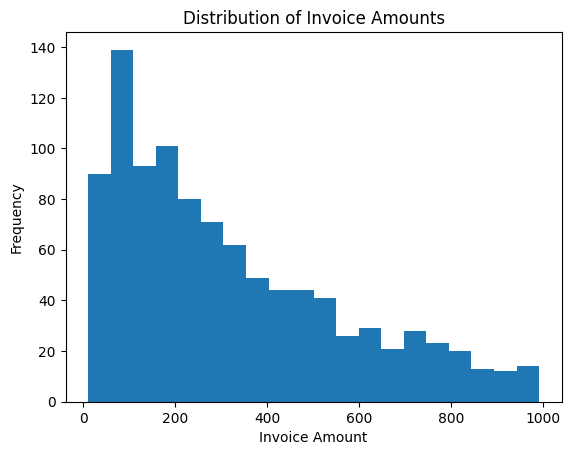

In [35]:
import matplotlib.pyplot as plt

plt.hist(dataset["total"], bins=20)

plt.title("Distribution of Invoice Amounts")
plt.xlabel("Invoice Amount")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='unit_price', ylabel='Density'>

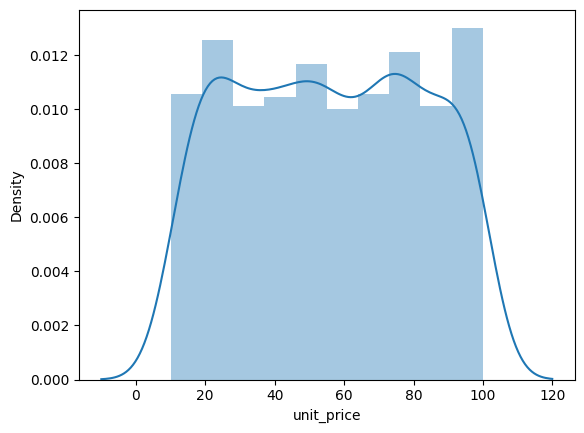

In [36]:
sns.distplot(dataset["unit_price"])

In [37]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    #generate a sample
    sample=dataset
    #Calculate parameters
    sample_mean= sample.mean()
    sample_std= sample.std()
    print('Mean=%.3f,Standard Deviation=%.3f'% (sample_mean,sample_std))
    # define the distribution
    dist=norm(sample_mean,sample_std)

    #sample probabilities for a range of outcomes
    values=[value for value in range (startrange,endrange)]
    probabilities =[dist.pdf(value) for value in values]
    prob=sum(probabilities)
    print("The area between range ({},{}):{} " .format(startrange,endrange,sum(probabilities))) 
    return prob

Mean=55.672,Standard Deviation=26.495
The area between range (40,60):0.28665273637491917 


np.float64(0.28665273637491917)

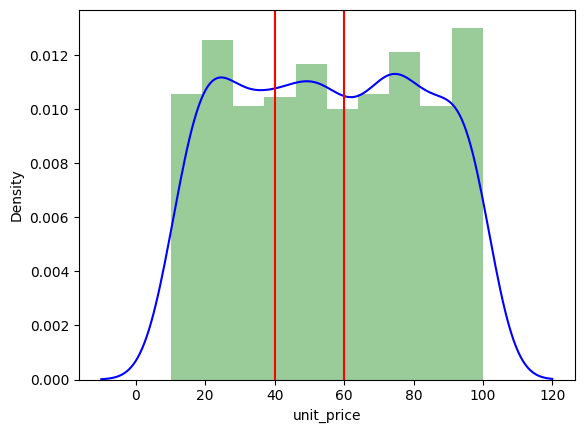

In [38]:
get_pdf_probability(dataset["unit_price"],40,60) 

In [39]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf=ECDF(dataset["unit_price"])
ecdf(78)

np.float64(0.751)

In [40]:
def stdNBgraph(dataset):
    #converted to std Norm Dist
    mean=dataset.mean()
    std=dataset.std()
    
    values=[i for i in dataset]
    
    z_score=[((j-mean)/std)for j in values]
    
    sns.distplot(z_score,kde=True)
    np=sum(z_score)/len(z_score)

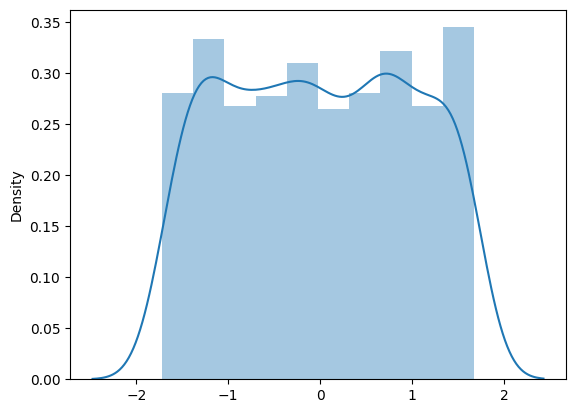

In [41]:
stdNBgraph(dataset["unit_price"])

# Bivariate Analysis

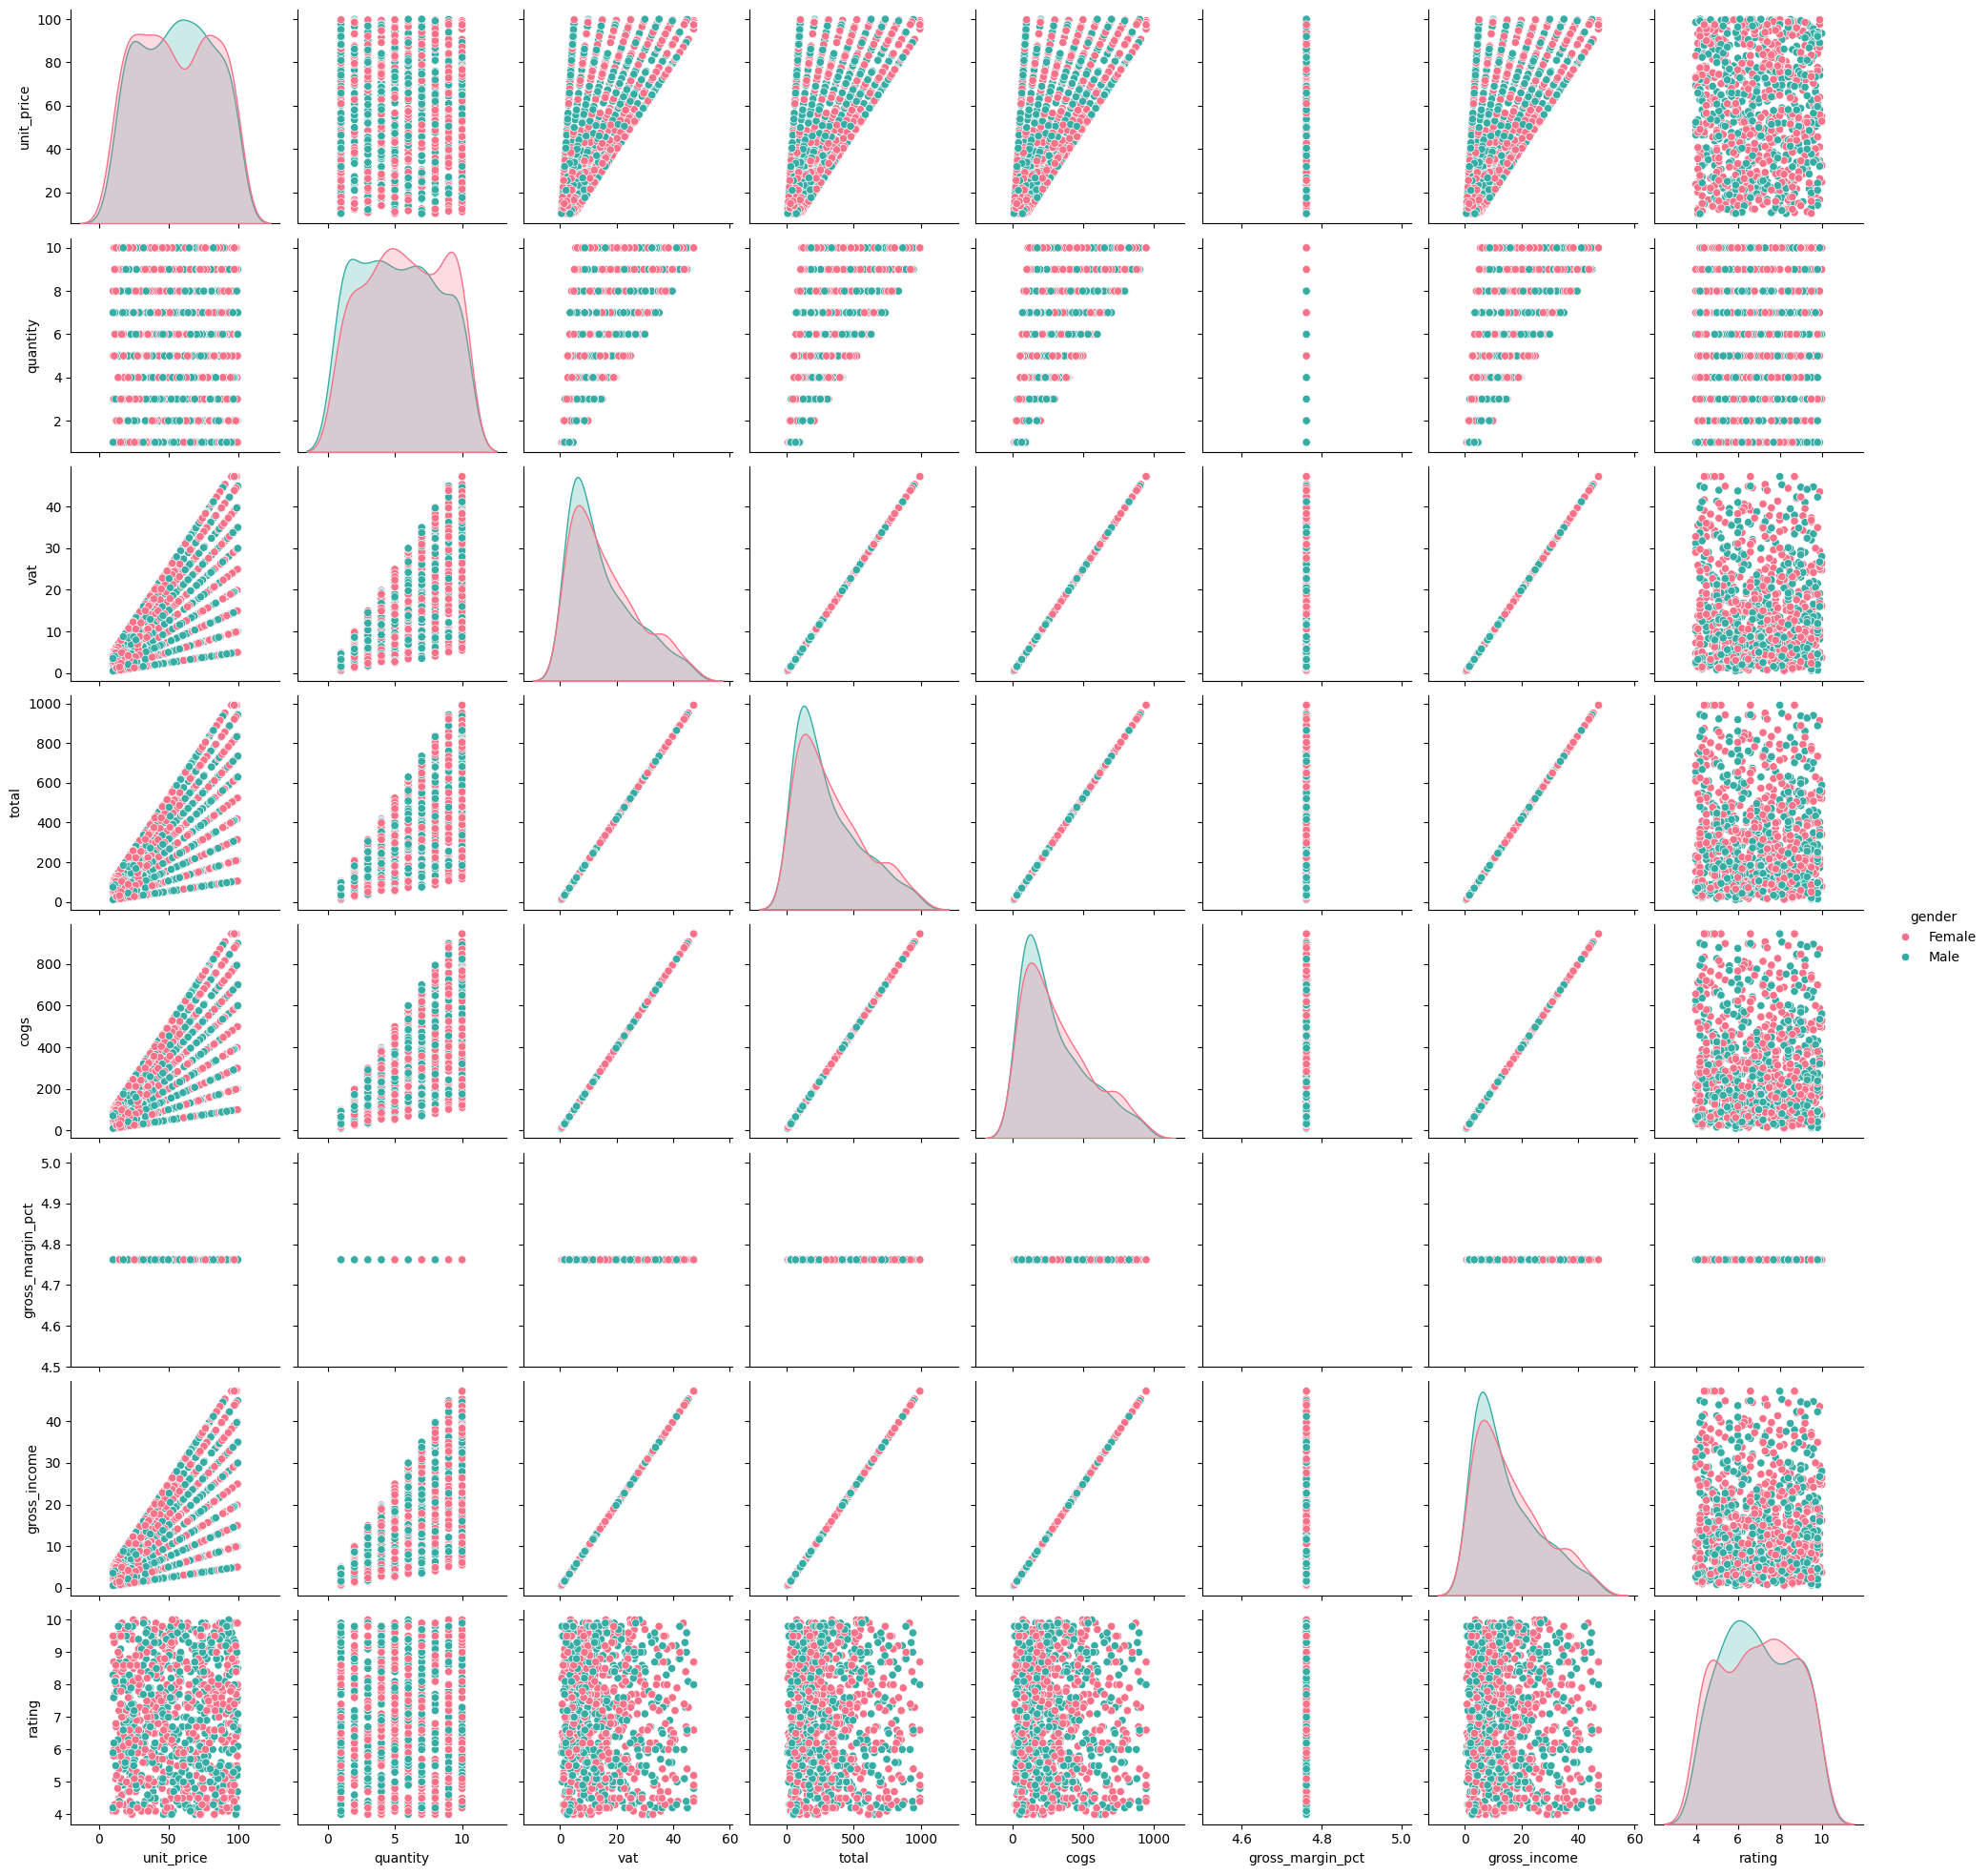

In [42]:
sns.pairplot(dataset,hue = 'gender',diag_kind = "kde",kind = "scatter",palette = "husl")
plt.show()

# 1.Is there a relationship between Quantity and Invoice total Amount?

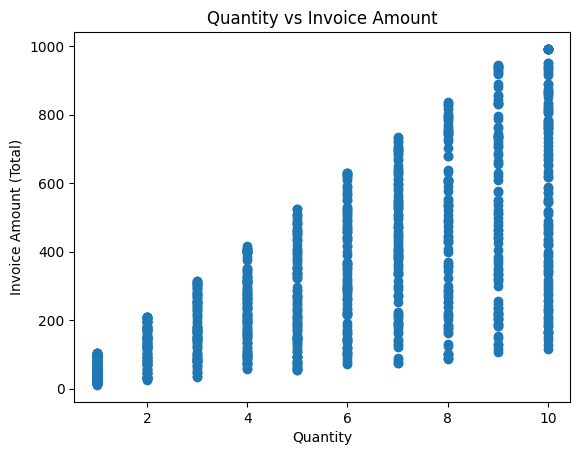

In [43]:
plt.scatter(dataset['quantity'], dataset['total'])
plt.xlabel('Quantity')
plt.ylabel('Invoice Amount (Total)')
plt.title('Quantity vs Invoice Amount')
plt.show()

# 2. Does Unit Price affect Total Sales?

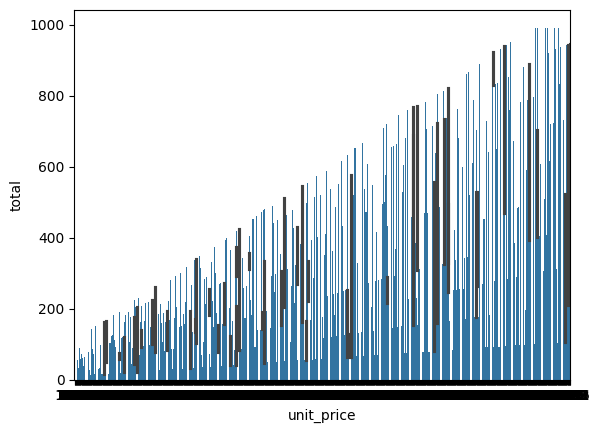

In [44]:
sns.barplot(x = "unit_price", y = "total", data = dataset)
plt.show()


# 3. What is the correlation between tax and total amount?

In [45]:
correlation_tax_total = dataset[['vat', 'total']].corr()
print("Correlation between vat and total:\n", correlation_tax_total)

Correlation between vat and total:
        vat  total
vat    1.0    1.0
total  1.0    1.0


# 4. Do higher quantities always lead to higher revenue?

quantity
1      57.520969
2     120.822000
3     178.685500
4     231.632312
5     265.209926
6     351.583714
7     428.084897
8     474.309459
9     530.254908
10    585.236879
Name: total, dtype: float64


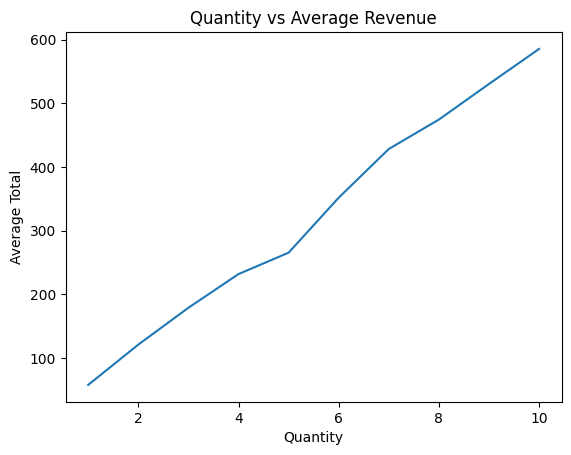

In [47]:
# Group by Quantity and find average total
grouped = dataset.groupby('quantity')['total'].mean()

print(grouped.head(10))

# Plot
grouped.plot()
plt.xlabel('Quantity')
plt.ylabel('Average Total')
plt.title('Quantity vs Average Revenue')
plt.show()

# 5. Which Product line generates more revenue?

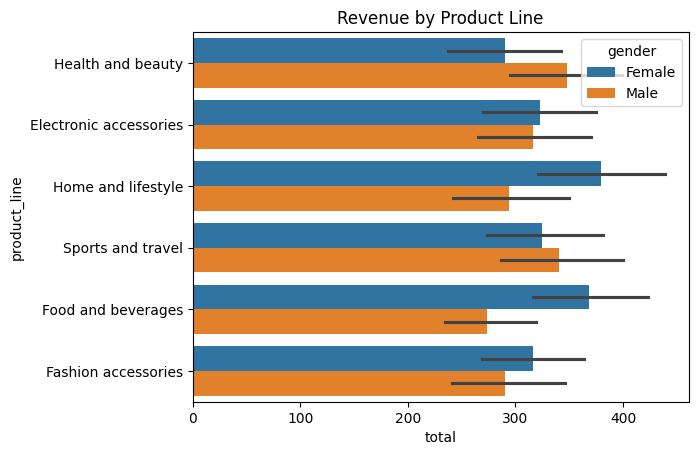

In [48]:
sns.barplot(x='total', y='product_line', data=dataset, hue='gender')
plt.title('Revenue by Product Line')
plt.show()

# 6. Which City has the highest average sales?

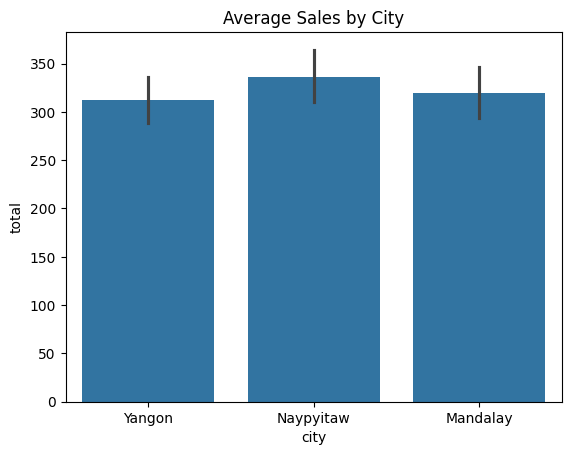

In [49]:
sns.barplot(x='city', y='total', data=dataset)
plt.title('Average Sales by City')
plt.show()